In [ ]:
# TODO

✅ extract ball centers per frame
✅ save CSV of ball trajectory
✅ apply Kalman smoothing
✅ overlay ball trail on the video
✅ create a side-by-side comparison
❇️ fully modular helper functions so you don’t re-copy code

In [ ]:
%conda install -y -c conda-forge ultralytics opencv matplotlib

In [11]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import ultralytics
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
import pandas as pd
import numpy as np

from utils.io_utils import load_config
from utils.io_utils import load_csv_folder
from utils.io_utils import pick_folder

from utils.preprocess_utils import crop_to_freethrow

from utils.align_freethrows_utils import apply_shift_to_dataset

from utils.visualize_freethrow_utils import FreeThrowVisualizer


# Load Config 
project_cfg = load_config("project_config.yaml")
ATHLETE = project_cfg["athlete"]
SESSION = project_cfg["session"]

base_dir = Path().resolve().parents[1]
session_dir = base_dir / "data" / ATHLETE / SESSION
metrics_dir = Path(f"../data/{ATHLETE}/{SESSION}/metrics")

raw_freethrow_phases_path = metrics_dir / "freethrow_phases.csv"
cropped_phases_path = metrics_dir /  "cropped_freethrow_phases.csv"
cropped_phases_df = pd.read_csv(cropped_phases_path)
shift_table_path = metrics_dir / "alignment_shift_table.csv" 

raw_ball_trajectory_path = metrics_dir / "raw_ball_trajectory"
raw_ball_trajectory_path.mkdir(parents=True, exist_ok=True)

# TODO make a function that loads all necessary data frames from data directory 

# Load CSVs
raw_freethrow_phases_df: pd.DataFrame = pd.read_csv(raw_freethrow_phases_path)
cropped_freethrow_phases_df: pd.DataFrame = pd.read_csv(raw_freethrow_phases_path)
angles_unsigned_area_log_df: pd.DataFrame = pd.read_csv(shift_table_path)

print("Ultralytics version:", ultralytics.__version__)

# model = YOLO("yolo11s.pt") # did not recognize as many 
model = YOLO("yolo11m.pt")
print("Loaded model:", model)

Ultralytics version: 8.3.233
Loaded model: YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(192, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(256, ep


image 1/1 /Users/kwill55/RVL/personalized-sports-optimization/notebooks/ball_image_2.png: 736x1280 2 persons, 1 sports ball, 1 chair, 546.8ms
Speed: 9.1ms preprocess, 546.8ms inference, 15.5ms postprocess per image at shape (1, 3, 736, 1280)


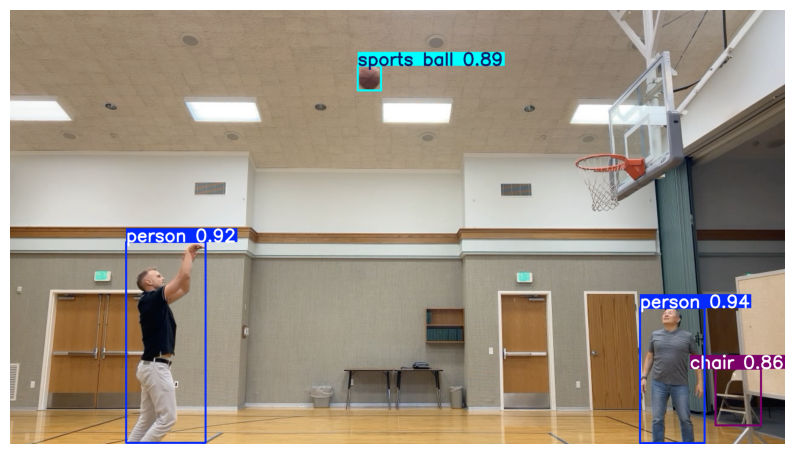

In [2]:
# ============================
# Run Model on a single image
# ============================

# Path to test image
img_path = "ball_image_2.png"

# Run YOLO on the image
# results = model(img_path)
results = model(img_path, imgsz=1280)

img = results[0].plot() # BGR       
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 

# Plot image within notebook
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)   # renders YOLO boxes directly
plt.axis("off")
plt.show()

In [ ]:
# ============================
# Run model on single video 
# ============================

video_path = "../data/tyler_haws/session_with_tyler_haws_gym/videos/ball_tracking/raw/freethrow002.avi"
model.predict(source=video_path, save=True, conf=0.15)


# TODO -- add dataset of balls near rim/net in order to have the model see them. also try turning up resolution, lowering confidence, etc 

In [ ]:
# ==================================================================
# Run model on all free throws in session and compute ball locations
# ==================================================================

folder = pick_folder(session_dir)
if folder is None:
    raise ValueError("No folder selected.")

# Collect all free-throw videos
video_files = sorted([
    f for f in folder.iterdir()
    if f.suffix.lower() in [".avi", ".mp4"]
])

print(f"Found {len(video_files)} videos")

raw_ball_trajectory_dfs: dict[str, pd.DataFrame] = {}

for video_path in video_files:

    print(f"\nProcessing: {video_path.name}")

    cap = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # === Create full-length DataFrame with NaNs ===
    df = pd.DataFrame({
        "frame": np.arange(total_frames),
        "x": np.nan,
        "y": np.nan
    })

    frame_idx = 0

    # Process frames
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame, verbose=False, conf=0.15)

        # For each detected object
        for box in results[0].boxes:
            if int(box.cls[0]) == 32:  # sports ball
                x1, y1, x2, y2 = box.xyxy[0] # YOLO function .xyxy
                cx = float((x1 + x2) / 2)
                cy = float((y1 + y2) / 2)

                # Fill into padded DataFrame
                df.loc[frame_idx, "ball_x"] = cx
                df.loc[frame_idx, "ball_y"] = cy

        frame_idx += 1

    cap.release()

    # Save into dict
    freethrow_name = video_path.stem
    raw_ball_trajectory_dfs[freethrow_name] = df

    # Save CSV
    df.to_csv(raw_ball_trajectory_path, index=False)

    # Print coverage
    detected_frames = df["x"].notna().sum()
    print(f"Detected ball in {detected_frames}/{total_frames} frames.")
    print(f"Saved trajectory → {raw_ball_trajectory_path}")

print("\nFinished processing all videos.")

Found 143 videos

Processing: freethrow001.avi
Detected ball in 24/46 frames.
Saved trajectory → ../data/tyler_haws/session_with_tyler_haws_gym/metrics/ball_trajectory_raw/freethrow001.csv

Processing: freethrow002.avi
Detected ball in 152/170 frames.
Saved trajectory → ../data/tyler_haws/session_with_tyler_haws_gym/metrics/ball_trajectory_raw/freethrow002.csv

Processing: freethrow003.avi
Detected ball in 164/183 frames.
Saved trajectory → ../data/tyler_haws/session_with_tyler_haws_gym/metrics/ball_trajectory_raw/freethrow003.csv

Processing: freethrow004.avi
Detected ball in 93/112 frames.
Saved trajectory → ../data/tyler_haws/session_with_tyler_haws_gym/metrics/ball_trajectory_raw/freethrow004.csv

Processing: freethrow005.avi
Detected ball in 129/149 frames.
Saved trajectory → ../data/tyler_haws/session_with_tyler_haws_gym/metrics/ball_trajectory_raw/freethrow005.csv

Processing: freethrow006.avi
Detected ball in 106/133 frames.
Saved trajectory → ../data/tyler_haws/session_with_ty

KeyboardInterrupt: 


✅ Successfully cropped 47 out of 49 freethrow sequences.

✅ Successfully aligned 47 out of 47 freethrow sequences.


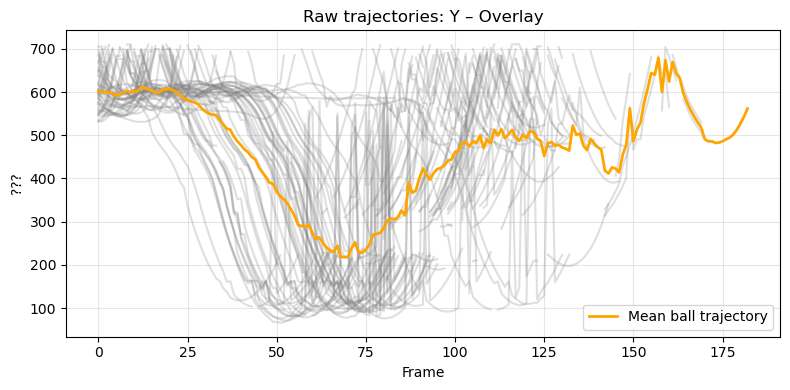

/Users/kwill55/RVL/personalized-sports-optimization/src/utils/visualize_freethrow_utils.py:69: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
/Users/kwill55/RVL/personalized-sports-optimization/src/utils/visualize_freethrow_utils.py:100: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves, axis=0)
/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


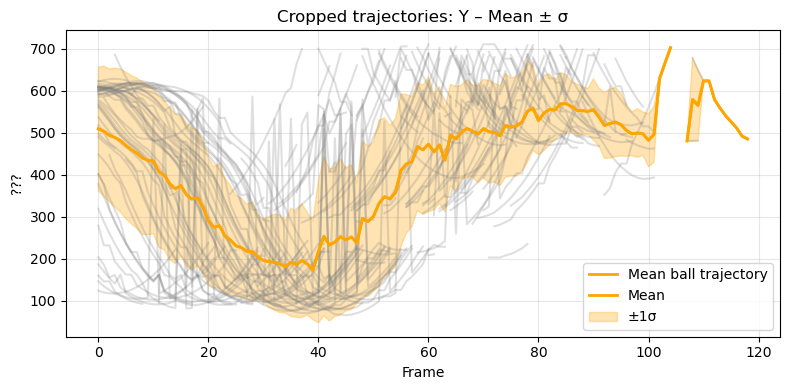

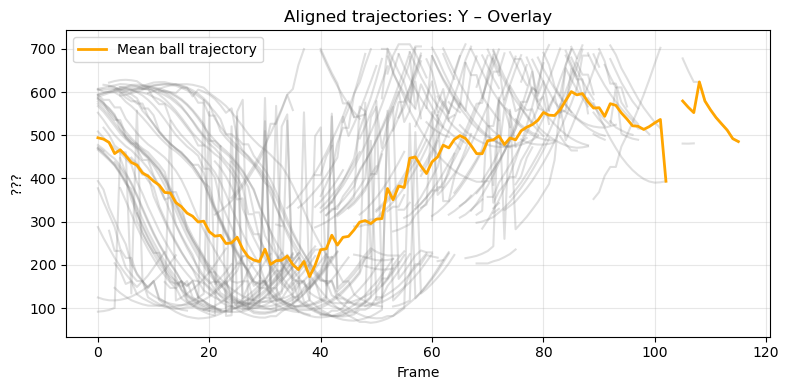

In [15]:
# ==================================================================
# Crop, align and plot ball trajectories 
# ==================================================================
ball_cols = ["x", "y"] #TODO rename all dataframes from x to ball_x by running previous segment 
curve_names = ["y"]

raw_ball_trajectory_dfs: dict[str, pd.DataFrame] = load_csv_folder(raw_ball_trajectory_path)

cropped_ball_trajectory_dfs = crop_to_freethrow(raw_ball_trajectory_dfs, raw_freethrow_phases_df)

aligned_ball_trajectory_dfs = apply_shift_to_dataset(
    original_dfs=cropped_ball_trajectory_dfs,
    log_df=angles_unsigned_area_log_df,
    joint_cols=ball_cols 
)

viz = FreeThrowVisualizer(
    y_label="???",
    title_label="Ball Trajectory"
)

viz.plot_multiple_curves(
    raw_ball_trajectory_dfs,
    curve_names,
    dataset_name="Raw trajectories",
    cropped_phases_df=cropped_freethrow_phases_df,
    show_overlay=True,
    show_mean_std=False,
    show_release_line=False
)

viz.plot_multiple_curves(
    cropped_ball_trajectory_dfs,
    curve_names,
    dataset_name="Cropped trajectories",
    cropped_phases_df=cropped_freethrow_phases_df,
    show_overlay=True,
    show_mean_std=True,
    show_release_line=False
)

viz.plot_multiple_curves(
    aligned_ball_trajectory_dfs,
    curve_names,
    dataset_name="Aligned trajectories",
    cropped_phases_df=cropped_freethrow_phases_df,
    show_overlay=True,
    show_mean_std=False,
    show_release_line=False
)

In [ ]:
dataset structure in files: 

dataset/
   images/
       train/
       val/
   labels/
       train/
       val/
data.yaml


data.yaml file: 

train: dataset/images/train
val: dataset/images/val

names:
  0: sports_ball

In [ ]:
#Train YOLO on Mac

model = YOLO("yolov11s.pt")

model.train(
    data="data.yaml",
    epochs=10,
    imgsz=640,
    batch=8
)
